# Requirement 2 — Multiple Campaigns, Stochastic Environment

Multiple advertising campaigns share a single budget and compete simultaneously in independent first-price auctions. The learner must choose a **joint action** — a bid for each campaign — subject to two constraints:

- **Budget:** the expected cost across all campaigns per round must not exceed $\rho = B/T$.
- **Conflict graph:** certain campaign pairs cannot both receive a bid in the same round. Here campaigns 0–1 and campaigns 2–3 are pairwise exclusive: $\{(0,1),(2,3)\}$.

**Algorithm: Combinatorial UCB.** At each round the agent maintains UCB/LCB confidence bounds for the reward and cost of every (campaign, bid) cell. It solves a joint LP over all $N$ campaigns subject to the budget and conflict-graph constraints, obtaining a distribution over feasible joint actions, and then samples one action.

**Clairvoyant benchmark:** the LP optimum computed once from the true stationary win probabilities $p_i(b) = \Pr(b \geq m_i)$ for each campaign $i$.

In [4]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / "picklefiles"
OUTPUTS_DIR = ROOT / "outputs"

def load_pickle(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the experiment cell first.")
    with path.open("rb") as f:
        return pickle.load(f)

def show_png(relative_path, width=900):
    path = OUTPUTS_DIR / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Missing plot:* `{path}` — run the experiment cell first."))

2026-07-09 14:38:57,606 INFO ============================================================
2026-07-09 14:38:57,609 INFO Requirement 2 – Multiple Campaigns, Stochastic Environment
2026-07-09 14:38:57,617 INFO ============================================================
2026-07-09 14:38:57,618 INFO Parameters | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]
2026-07-09 14:38:57,626 INFO MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]
2026-07-09 14:38:57,662 INFO Clairvoyant | opt_utility_per_round=0.0952
2026-07-09 14:38:57,662 INFO Running 20 trials – req2_comb_ucb
2026-07-09 14:38:57,662 INFO CombinatorialUCBAgent | N=4 Ks=[9, 9, 10, 10] T=10000 B=1600.0 rho=0.1600 edges=[(0, 1), (2, 3)]
2026-07-09 14:39:51,846 INFO CombinatorialUCBAgent | N=4 Ks=[9, 9, 10, 10] T=10000 B=1600.0 rho=0.1600 edges=[(0, 1), (2, 3)]
2026-07-09 14:40:48,817 INFO CombinatorialUCBAgent | N=4 Ks=[9, 9, 10, 10] T=10000 B=1600.0 rho=0.1600 edges=[(0, 1), (2, 3)]
2

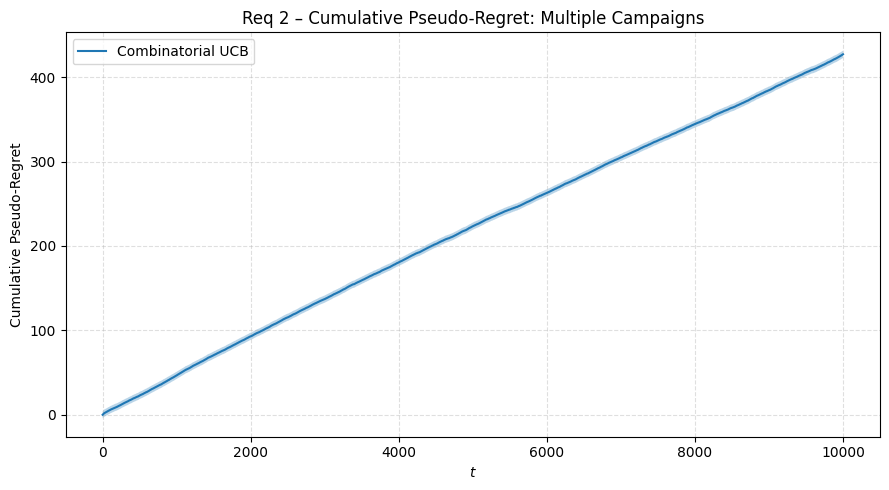

2026-07-09 15:02:28,189 INFO Saved plot to C:\Users\giuli\Repositories\ola\outputs\req2\budget.png


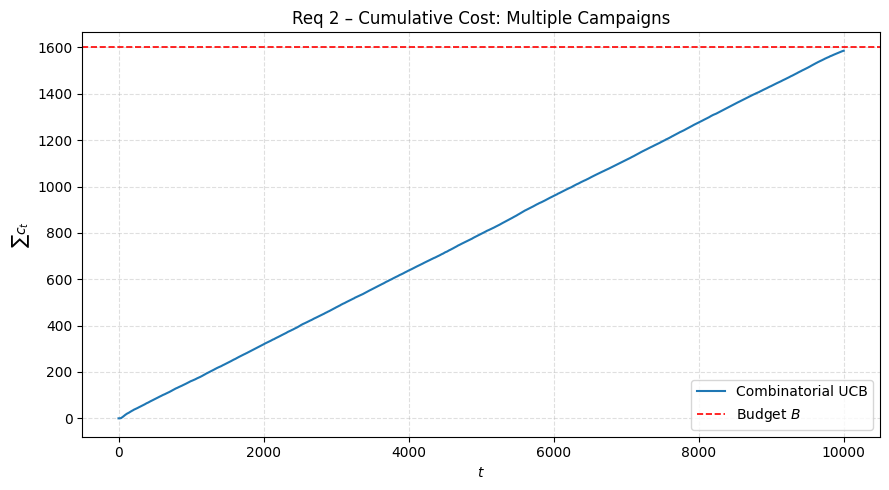

2026-07-09 15:02:28,590 INFO Saved average regret plot to C:\Users\giuli\Repositories\ola\outputs\req2\average_regret.png


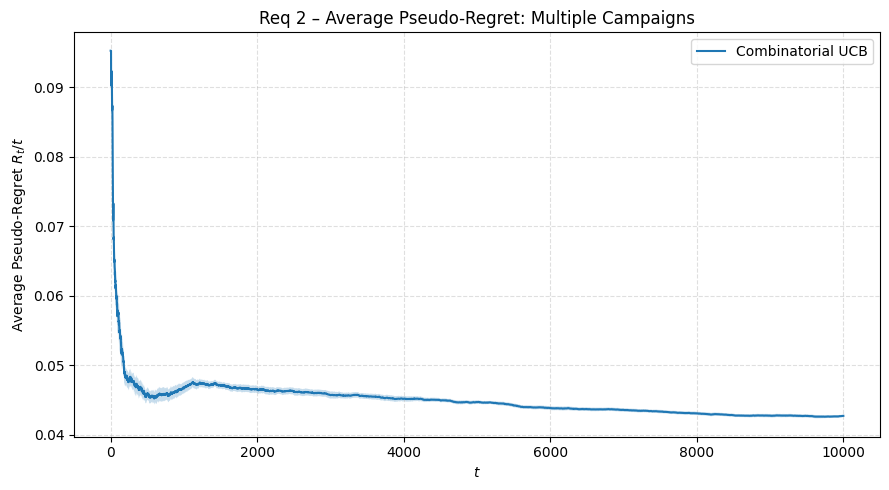

2026-07-09 15:02:29,236 INFO Saved multi-campaign bid distribution plot to C:\Users\giuli\Repositories\ola\outputs\req2\highest_competing_bid_distributions.png


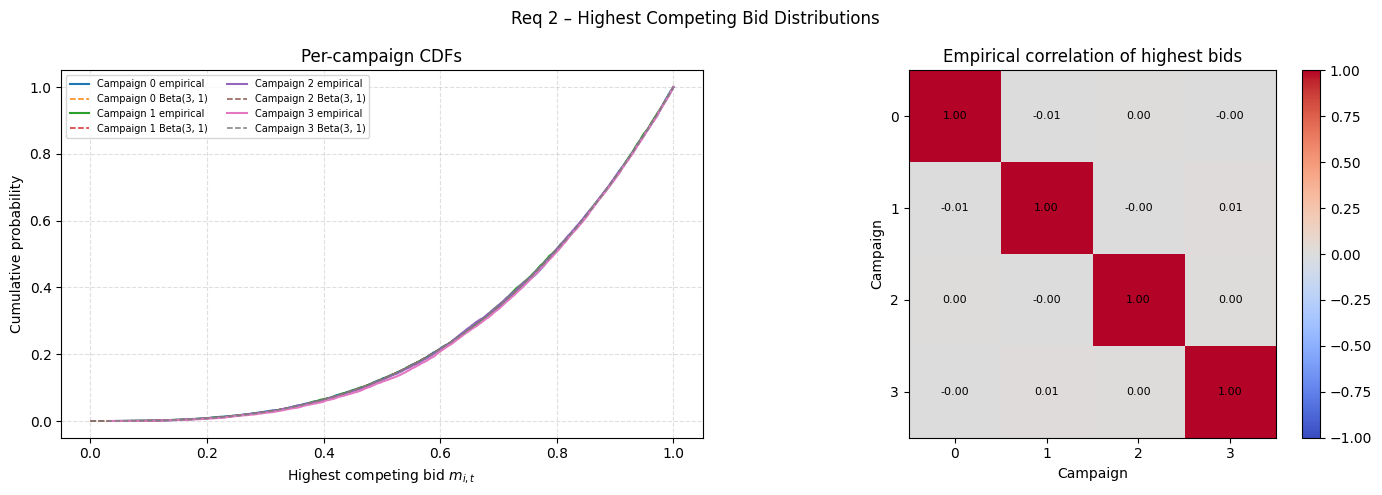

2026-07-09 15:02:30,586 INFO Saved pairwise joint bid distribution plot to C:\Users\giuli\Repositories\ola\outputs\req2\pairwise_joint_bid_distributions.png


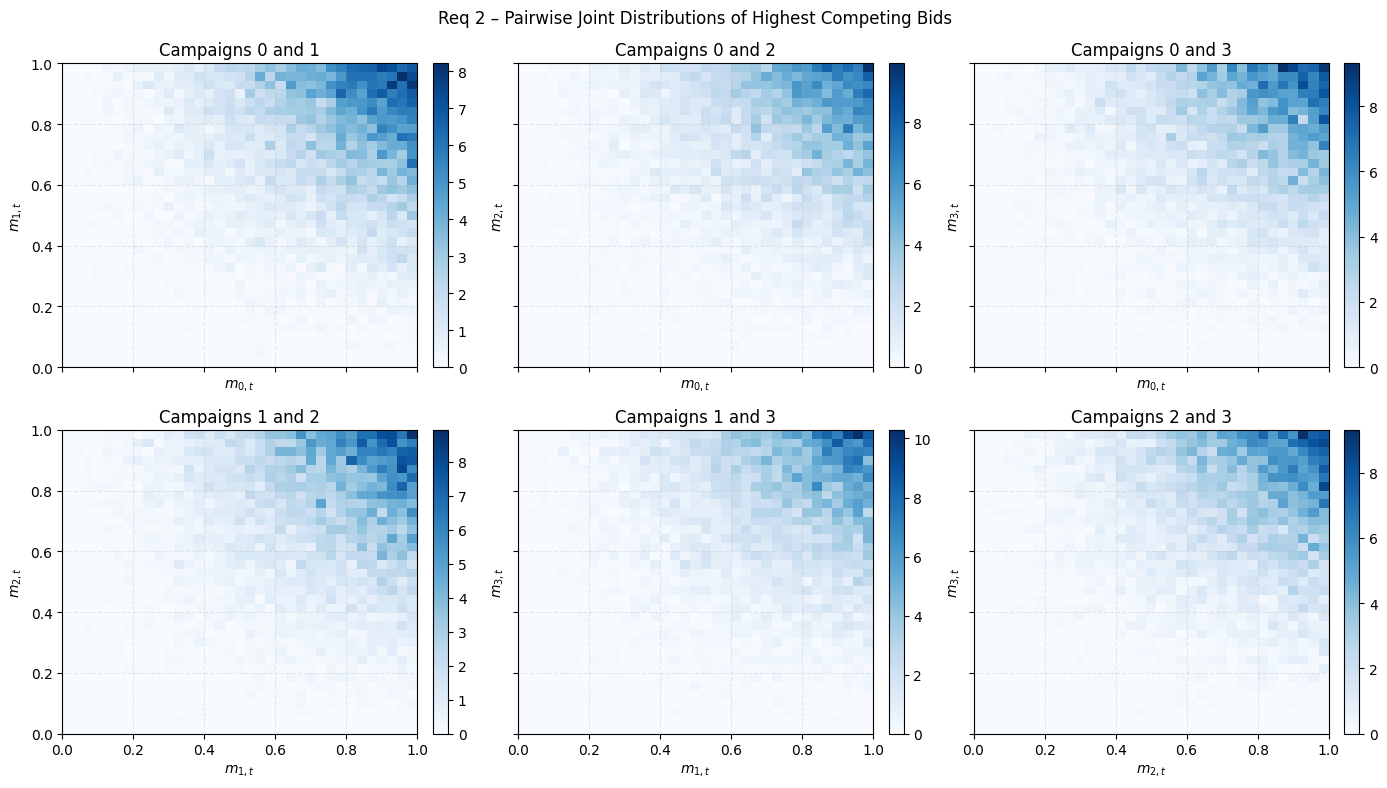

2026-07-09 15:02:31,220 INFO Exploration/exploitation transition annotated at t=2823
2026-07-09 15:02:31,556 INFO Saved annotated plot to C:\Users\giuli\Repositories\ola\outputs\req2\regret_annotated.png


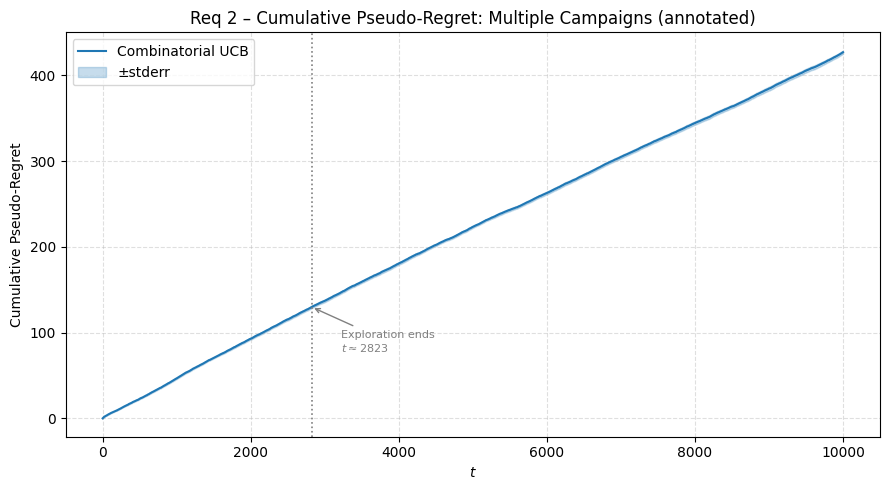

2026-07-09 15:02:31,719 INFO Requirement 2 complete.


In [5]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

from utils.run_req2 import run_req2
run_req2()

## Parameters

The implementation lives in `utils/run_req2.py`. Problem parameters are shared with Requirements 3 and 4 via `utils/req3_config.py`.

In [6]:
from utils.req3_config import VALUES, T, BUDGET, N_TRIALS, N_COMPETITORS, CONFLICT_EDGES, AVAILABLE_BIDS
from utils.environments import MultiCampaignEnv

env = MultiCampaignEnv(
    values=VALUES, budget=BUDGET, T=T,
    available_bids=AVAILABLE_BIDS, n_competitors=N_COMPETITORS,
    conflict_edges=CONFLICT_EDGES, seed=0,
)

print(f"Campaigns N     = {env.N}")
print(f"Values          = {VALUES}")
print(f"Bid-set sizes   = {env.Ks}")
print(f"Horizon T       = {T}")
print(f"Budget B        = {BUDGET}  (ρ = {BUDGET/T:.4f})")
print(f"Trials          = {N_TRIALS}")
print(f"Competitors     = {N_COMPETITORS}")
print(f"Conflict edges  = {CONFLICT_EDGES}")

2026-07-09 15:02:32,115 INFO MultiCampaignEnv | N=4 T=10000 B=1600.0 rho=0.1600 conflict_edges=[(0, 1), (2, 3)]


Campaigns N     = 4
Values          = [0.8, 0.8, 0.9, 0.9]
Bid-set sizes   = [9, 9, 10, 10]
Horizon T       = 10000
Budget B        = 1600.0  (ρ = 0.1600)
Trials          = 20
Competitors     = [3, 3, 3, 3]
Conflict edges  = [(0, 1), (2, 3)]


## Clairvoyant LP

The benchmark knows the true per-campaign win probabilities $p_i(b)$ and solves a joint LP over all $N=4$ campaigns maximising total expected utility subject to the shared budget rate $\rho$ and the conflict-graph constraints. With $K=11$ bids per campaign the LP has 44 primal variables.

In [7]:
from utils.experiments import compute_clairvoyant_multi

win_probs = env.win_probabilities()
clairvoyant_marginals, opt_utility = compute_clairvoyant_multi(
    values=np.array(VALUES), bid_sets=env.bid_sets, rho=BUDGET / T,
    win_prob_list=win_probs, conflict_edges=CONFLICT_EDGES,
)
print(f"Clairvoyant utility/round: {opt_utility:.5f}  (ρ = {BUDGET/T:.4f})")

Clairvoyant utility/round: 0.09522  (ρ = 0.1600)


## Campaign Bid Table

Expected utility, expected cost, and clairvoyant marginal probability for each (campaign, bid) pair. The LP concentrates mass on a small number of bids per campaign.

In [8]:
rows = ["| Cmp | Value | Bid | P(win) | E[utility] | E[cost] | Clairvoyant γ |",
        "| --- | --- | --- | --- | --- | --- | --- |"]
for i in range(env.N):
    for bid, wp, m in zip(env.bid_sets[i], win_probs[i], clairvoyant_marginals[i]):
        rows.append(
            f"| {i} | {VALUES[i]:.2f} | {bid:.2f} | {wp:.4f} | "
            f"{(VALUES[i]-bid)*wp:.4f} | {bid*wp:.4f} | {m:.4f} |"
        )
display(Markdown("\n".join(rows)))

| Cmp | Value | Bid | P(win) | E[utility] | E[cost] | Clairvoyant γ |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.80 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 0 | 0.80 | 0.10 | 0.0010 | 0.0007 | 0.0001 | 0.0000 |
| 0 | 0.80 | 0.20 | 0.0080 | 0.0048 | 0.0016 | 0.0000 |
| 0 | 0.80 | 0.30 | 0.0270 | 0.0135 | 0.0081 | 0.0000 |
| 0 | 0.80 | 0.40 | 0.0640 | 0.0256 | 0.0256 | 0.0000 |
| 0 | 0.80 | 0.50 | 0.1250 | 0.0375 | 0.0625 | 1.0000 |
| 0 | 0.80 | 0.60 | 0.2160 | 0.0432 | 0.1296 | 0.0000 |
| 0 | 0.80 | 0.70 | 0.3430 | 0.0343 | 0.2401 | 0.0000 |
| 0 | 0.80 | 0.80 | 0.5120 | 0.0000 | 0.4096 | 0.0000 |
| 1 | 0.80 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 1 | 0.80 | 0.10 | 0.0010 | 0.0007 | 0.0001 | 0.0000 |
| 1 | 0.80 | 0.20 | 0.0080 | 0.0048 | 0.0016 | 0.0000 |
| 1 | 0.80 | 0.30 | 0.0270 | 0.0135 | 0.0081 | 0.0000 |
| 1 | 0.80 | 0.40 | 0.0640 | 0.0256 | 0.0256 | 0.0000 |
| 1 | 0.80 | 0.50 | 0.1250 | 0.0375 | 0.0625 | 0.0000 |
| 1 | 0.80 | 0.60 | 0.2160 | 0.0432 | 0.1296 | 0.0000 |
| 1 | 0.80 | 0.70 | 0.3430 | 0.0343 | 0.2401 | 0.0000 |
| 1 | 0.80 | 0.80 | 0.5120 | 0.0000 | 0.4096 | 0.0000 |
| 2 | 0.90 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 2 | 0.90 | 0.10 | 0.0010 | 0.0008 | 0.0001 | 0.0000 |
| 2 | 0.90 | 0.20 | 0.0080 | 0.0056 | 0.0016 | 0.0000 |
| 2 | 0.90 | 0.30 | 0.0270 | 0.0162 | 0.0081 | 0.0000 |
| 2 | 0.90 | 0.40 | 0.0640 | 0.0320 | 0.0256 | 0.0000 |
| 2 | 0.90 | 0.50 | 0.1250 | 0.0500 | 0.0625 | 0.4784 |
| 2 | 0.90 | 0.60 | 0.2160 | 0.0648 | 0.1296 | 0.5216 |
| 2 | 0.90 | 0.70 | 0.3430 | 0.0686 | 0.2401 | 0.0000 |
| 2 | 0.90 | 0.80 | 0.5120 | 0.0512 | 0.4096 | 0.0000 |
| 2 | 0.90 | 0.90 | 0.7290 | 0.0000 | 0.6561 | 0.0000 |
| 3 | 0.90 | 0.00 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 3 | 0.90 | 0.10 | 0.0010 | 0.0008 | 0.0001 | 0.0000 |
| 3 | 0.90 | 0.20 | 0.0080 | 0.0056 | 0.0016 | 0.0000 |
| 3 | 0.90 | 0.30 | 0.0270 | 0.0162 | 0.0081 | 0.0000 |
| 3 | 0.90 | 0.40 | 0.0640 | 0.0320 | 0.0256 | 0.0000 |
| 3 | 0.90 | 0.50 | 0.1250 | 0.0500 | 0.0625 | 0.0000 |
| 3 | 0.90 | 0.60 | 0.2160 | 0.0648 | 0.1296 | 0.0000 |
| 3 | 0.90 | 0.70 | 0.3430 | 0.0686 | 0.2401 | 0.0000 |
| 3 | 0.90 | 0.80 | 0.5120 | 0.0512 | 0.4096 | 0.0000 |
| 3 | 0.90 | 0.90 | 0.7290 | 0.0000 | 0.6561 | 0.0000 |

## Results Summary

Final cumulative pseudo-regret and budget utilisation from the multi-trial experiment.

In [ ]:
try:
    res = load_pickle("req2_comb_ucb_results.pkl")
except FileNotFoundError as _e:
    display(Markdown(f"**Run the `run_req2()` cell above first, then re-run this cell.**\n\n`{_e}`"))
    raise

T_run = len(res["mean_regret"])
print(f"Trials:          {res['n_trials']}")
print(f"Final regret:    {res['mean_regret'][-1]:.2f}")
print(f"Average regret:  {res['mean_regret'][-1] / T_run:.5f}")
print(f"Final cost:      {res['mean_cumcost'][-1]:.2f} / {BUDGET:.0f}")
print(f"Budget slack:    {BUDGET - res['mean_cumcost'][-1]:.2f}")
print(f"Mean cost/round: {res['mean_cumcost'][-1] / T_run:.5f}")